In [1]:
def seed_everything(seed=42):
    import os
    import random
    import numpy as np
    
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    
    print(f"全局随机种子已设置为: {seed}")

seed_everything(42)

全局随机种子已设置为: 42


In [2]:
import os
print(f"当前环境可用核心数: {os.cpu_count()}")

当前环境可用核心数: 16


baseline，直接采用三种特征的线性组合，不添加距离

In [3]:
import os
from scripts.data_utils import load_all_datasets, SCORES
from scripts.engine import run_cross_validation
import numpy as np

DATA_DIR = "/share/home/wangtb/enzyme_shells/activity_data"
OUT_DIR = "/share/home/wangtb/enzyme_shells/analysis"
OUT_NAME = "baseline.csv"

def predict(P, d, X):
    return P[0]*X[:,0] + P[1]*X[:,1] + P[2]*X[:,2] + P[3]

def objective(P, d, X, y_true, predict_fn, alpha=0.1):
    y_pred = predict_fn(P, d, X)
    
    s_diff = y_pred[:, None] - y_pred[None, :]
    y_diff = y_true[:, None] - y_true[None, :]
    mask = y_diff > 0
    valid_diffs = s_diff[mask]
    rank_loss = np.logaddexp(0, -valid_diffs).sum()
    
    l2_penalty = alpha * np.sum(P[:-1]**2)
    
    return rank_loss + l2_penalty

datasets = load_all_datasets(DATA_DIR)

num_params = 4
rng = np.random.RandomState(42)
p0 = rng.uniform(-1, 1, size=num_params)
print(f"初始参数: {p0}")

results_df = run_cross_validation(
    datasets, 
    predict_fn=predict, 
    objective_fn=objective, 
    p0=p0, 
    scores_cols=SCORES,
    alpha=0.1
)

if not os.path.exists(OUT_DIR): os.makedirs(OUT_DIR)
results_df.to_csv(os.path.join(OUT_DIR, OUT_NAME), index=False)
print("Done!")

初始参数: [-0.25091976  0.90142861  0.46398788  0.19731697]
正在启动任务：OTC.csv
正在启动任务：RUBISCO.csv
正在启动任务：CAS9.csv
正在启动任务：RASH.csv
正在启动任务：VKOR1.csv
正在启动任务：PTEN.csv
正在启动任务：PTEN_2018.csv
正在启动任务：LGK.csv
正在启动任务：AMIE.csv
正在启动任务：PAFA.csv
正在启动任务：AICDA.csv
正在启动任务：RNC.csv
Done!


baseline的结果

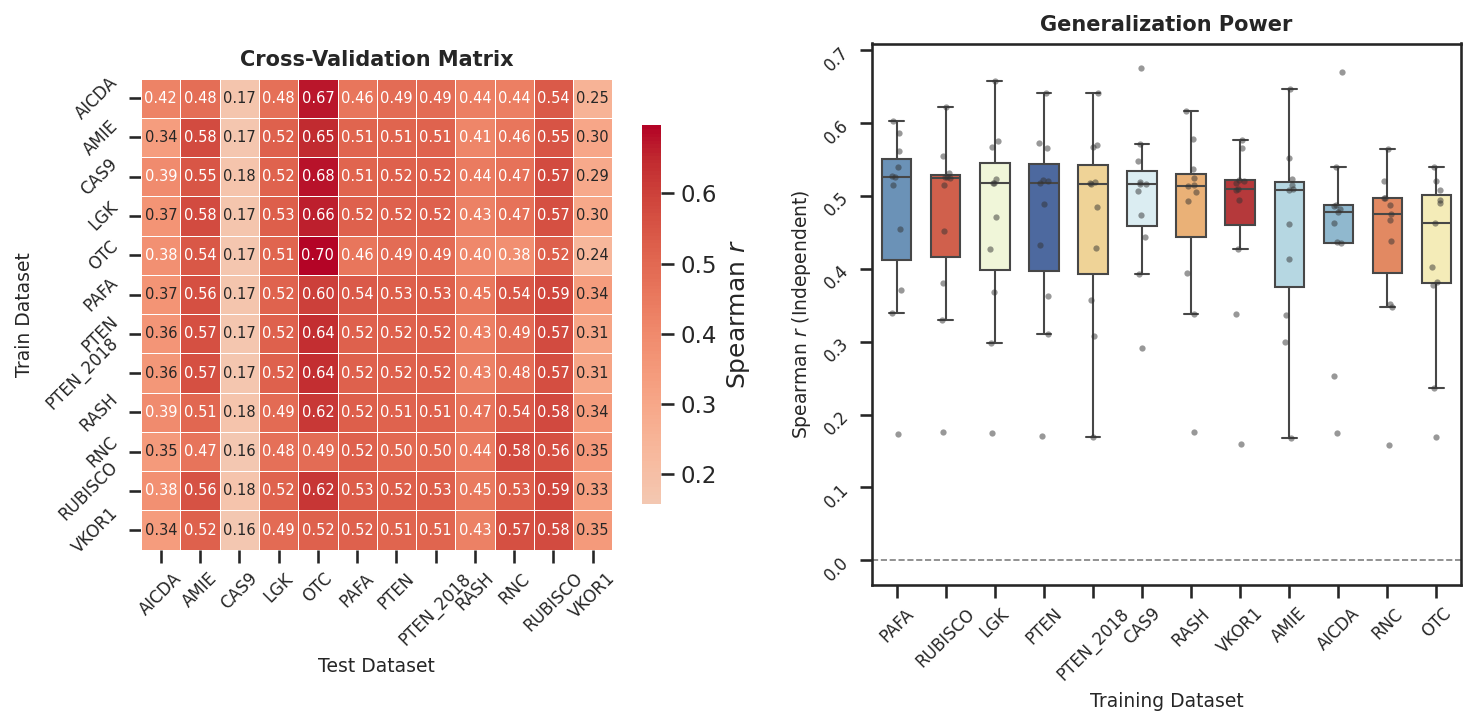

In [4]:
from scripts.plot import plot_cv_results

CSV_PATH = "/share/home/wangtb/enzyme_shells/analysis/baseline.csv"

plot_cv_results(CSV_PATH)

/share/home/wangtb/enzyme_shells/analysis/scripts/plot.py:104: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_delta.index, y=avg_delta.values, palette=colors, ax=ax2)
/share/home/wangtb/enzyme_shells/analysis/scripts/plot.py:115: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Model', y='r', data=df_long, palette="Pastel1", showfliers=False, ax=ax3, width=0.5)


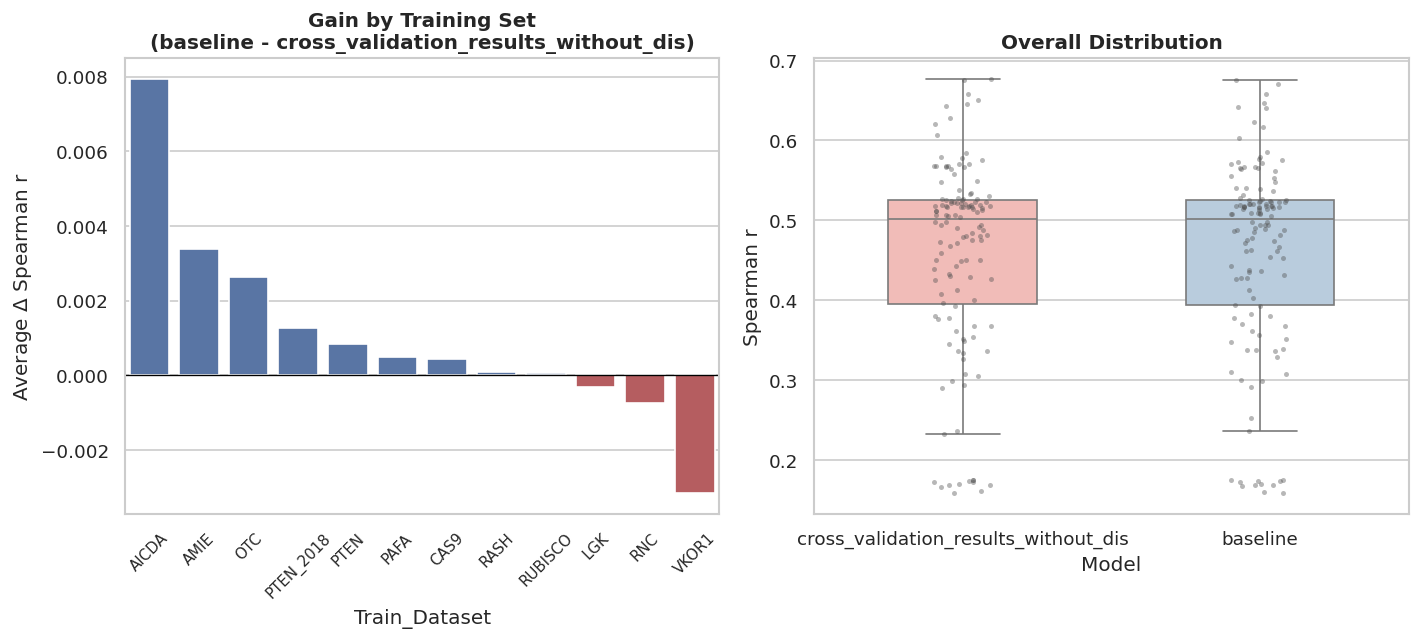

In [2]:
from scripts.plot import compare_cv_results

# 默认是 1 减去 2
CSV_1 = "/share/home/wangtb/enzyme_shells/analysis/cross_validation_results_without_dis.csv"
CSV_2 = "/share/home/wangtb/enzyme_shells/analysis/baseline.csv"

compare_cv_results(CSV_1, CSV_2)

linear combination 模型，三种特征加距离的线性组合

In [5]:
import os
from scripts.data_utils import load_all_datasets, SCORES
from scripts.engine import run_cross_validation
import numpy as np

DATA_DIR = "/share/home/wangtb/enzyme_shells/activity_data"
OUT_DIR = "/share/home/wangtb/enzyme_shells/analysis"
OUT_NAME = "linear.csv"

def predict(P, d, X):
    return P[0]*X[:,0] + P[1]*X[:,1] + P[2]*X[:,2] + P[3]*d + P[4]

def objective(P, d, X, y_true, predict_fn, alpha=0.1):
    y_pred = predict_fn(P, d, X)
    
    s_diff = y_pred[:, None] - y_pred[None, :]
    y_diff = y_true[:, None] - y_true[None, :]
    mask = y_diff > 0
    valid_diffs = s_diff[mask]
    rank_loss = np.logaddexp(0, -valid_diffs).sum()
    
    l2_penalty = alpha * np.sum(P[:-1]**2)
    
    return rank_loss + l2_penalty

datasets = load_all_datasets(DATA_DIR)

num_params = 5
rng = np.random.RandomState(42)
p0 = rng.uniform(-1, 1, size=num_params)
print(f"初始参数: {p0}")

results_df = run_cross_validation(
    datasets, 
    predict_fn=predict, 
    objective_fn=objective, 
    p0=p0, 
    scores_cols=SCORES,
    alpha=0.1
)

if not os.path.exists(OUT_DIR): os.makedirs(OUT_DIR)
results_df.to_csv(os.path.join(OUT_DIR, OUT_NAME), index=False)
print("Done!")

初始参数: [-0.25091976  0.90142861  0.46398788  0.19731697 -0.68796272]
正在启动任务：PTEN.csv
正在启动任务：PAFA.csv
正在启动任务：AICDA.csv
正在启动任务：AMIE.csv
正在启动任务：CAS9.csv
正在启动任务：LGK.csv
正在启动任务：OTC.csv
正在启动任务：PTEN_2018.csv
正在启动任务：RASH.csv
正在启动任务：RNC.csv
正在启动任务：RUBISCO.csv
正在启动任务：VKOR1.csv
Done!


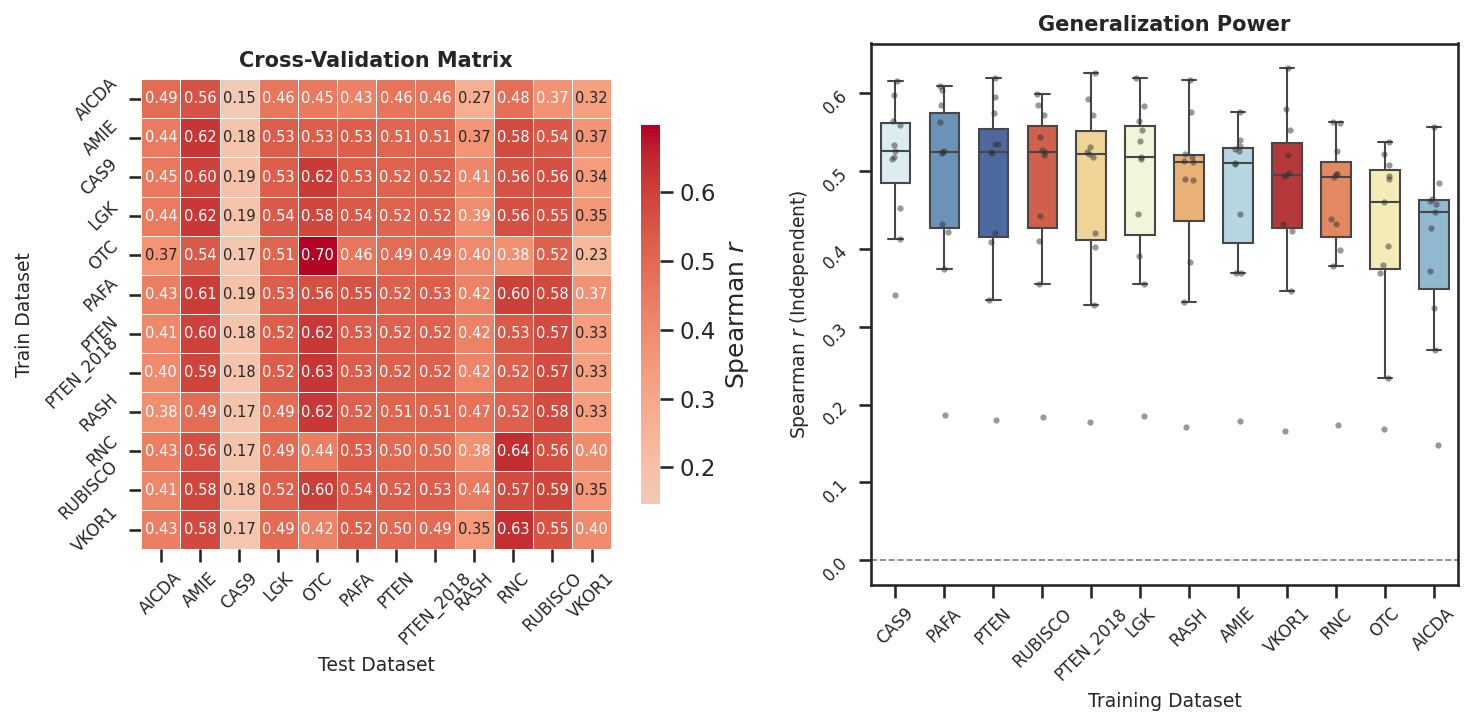

In [6]:
from scripts.plot import plot_cv_results

CSV_PATH = "/share/home/wangtb/enzyme_shells/analysis/linear.csv"

plot_cv_results(CSV_PATH)

将距离d加入线性组合中，综合的效果变好了

/share/home/wangtb/enzyme_shells/analysis/scripts/plot.py:104: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_delta.index, y=avg_delta.values, palette=colors, ax=ax2)
/share/home/wangtb/enzyme_shells/analysis/scripts/plot.py:115: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Model', y='r', data=df_long, palette="Pastel1", showfliers=False, ax=ax3, width=0.5)


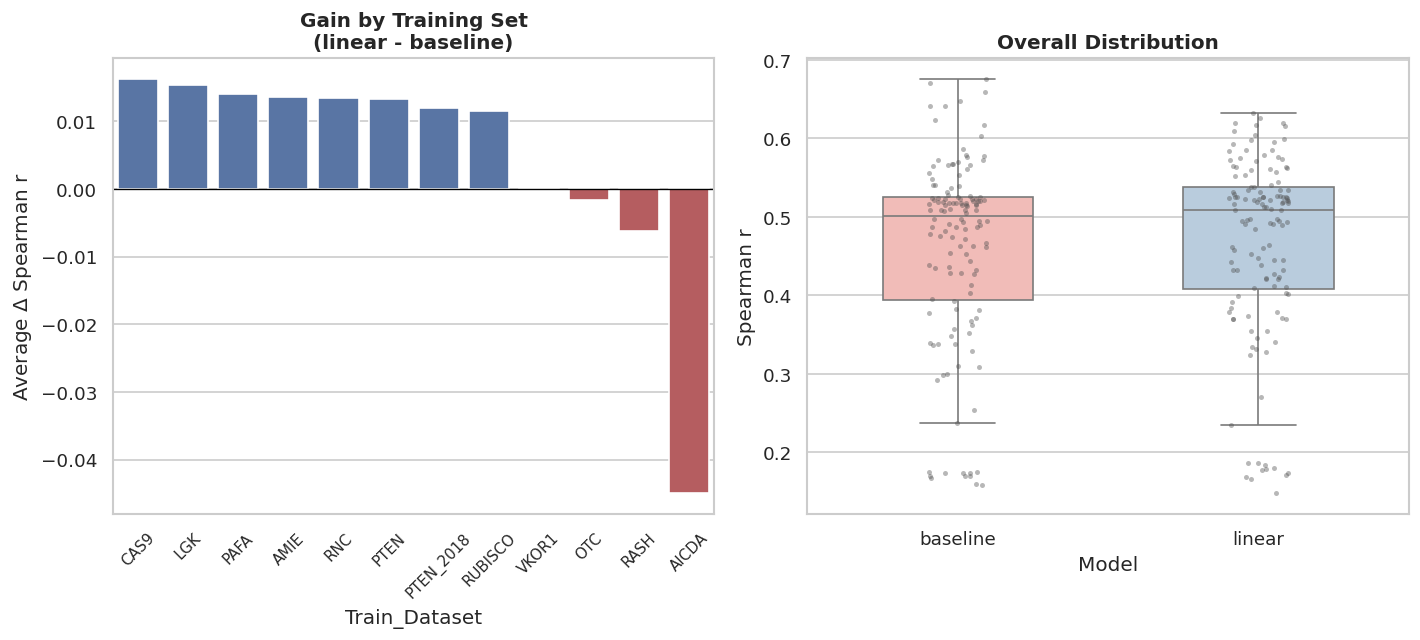

In [7]:
from scripts.plot import compare_cv_results

# 默认是 1 减去 2
CSV_1 = "/share/home/wangtb/enzyme_shells/analysis/baseline.csv"
CSV_2 = "/share/home/wangtb/enzyme_shells/analysis/linear.csv"

compare_cv_results(CSV_1, CSV_2)

对d作exp变换，作为权重，去加权三种特征

In [8]:
import os
from scripts.data_utils import load_all_datasets, SCORES
from scripts.engine import run_cross_validation
import numpy as np

DATA_DIR = "/share/home/wangtb/enzyme_shells/activity_data"
OUT_DIR = "/share/home/wangtb/enzyme_shells/analysis"
OUT_NAME = "exp_combination.csv"

def predict(P, d, X):
    y_pred = (
        P[0] * X[:,0] * np.exp(P[3] * d) +
        P[1] * X[:,1] * np.exp(P[4] * d) +
        P[2] * X[:,2] * np.exp(P[5] * d) +
        P[6]
    )
    return y_pred

def objective(P, d, X, y_true, predict_fn, alpha=0.1):
    y_pred = predict_fn(P, d, X)
    
    s_diff = y_pred[:, None] - y_pred[None, :]
    y_diff = y_true[:, None] - y_true[None, :]
    mask = y_diff > 0
    valid_diffs = s_diff[mask]
    rank_loss = np.logaddexp(0, -valid_diffs).sum()
    
    l2_penalty = alpha * np.sum(P[:-1]**2)
    
    return rank_loss + l2_penalty

datasets = load_all_datasets(DATA_DIR)

num_params = 7
rng = np.random.RandomState(42)
p0 = rng.uniform(-1, 1, size=num_params)
print(f"初始参数: {p0}")

results_df = run_cross_validation(
    datasets, 
    predict_fn=predict, 
    objective_fn=objective, 
    p0=p0, 
    scores_cols=SCORES,
    alpha=0.1
)

if not os.path.exists(OUT_DIR): os.makedirs(OUT_DIR)
results_df.to_csv(os.path.join(OUT_DIR, OUT_NAME), index=False)
print("Done!")

初始参数: [-0.25091976  0.90142861  0.46398788  0.19731697 -0.68796272 -0.68801096
 -0.88383278]
正在启动任务：PTEN.csv
正在启动任务：PAFA.csv
正在启动任务：AICDA.csv
正在启动任务：AMIE.csv
正在启动任务：CAS9.csv
正在启动任务：LGK.csv
正在启动任务：RNC.csv
正在启动任务：RASH.csv
正在启动任务：RUBISCO.csv
正在启动任务：PTEN_2018.csv
正在启动任务：OTC.csv
正在启动任务：VKOR1.csv
Done!


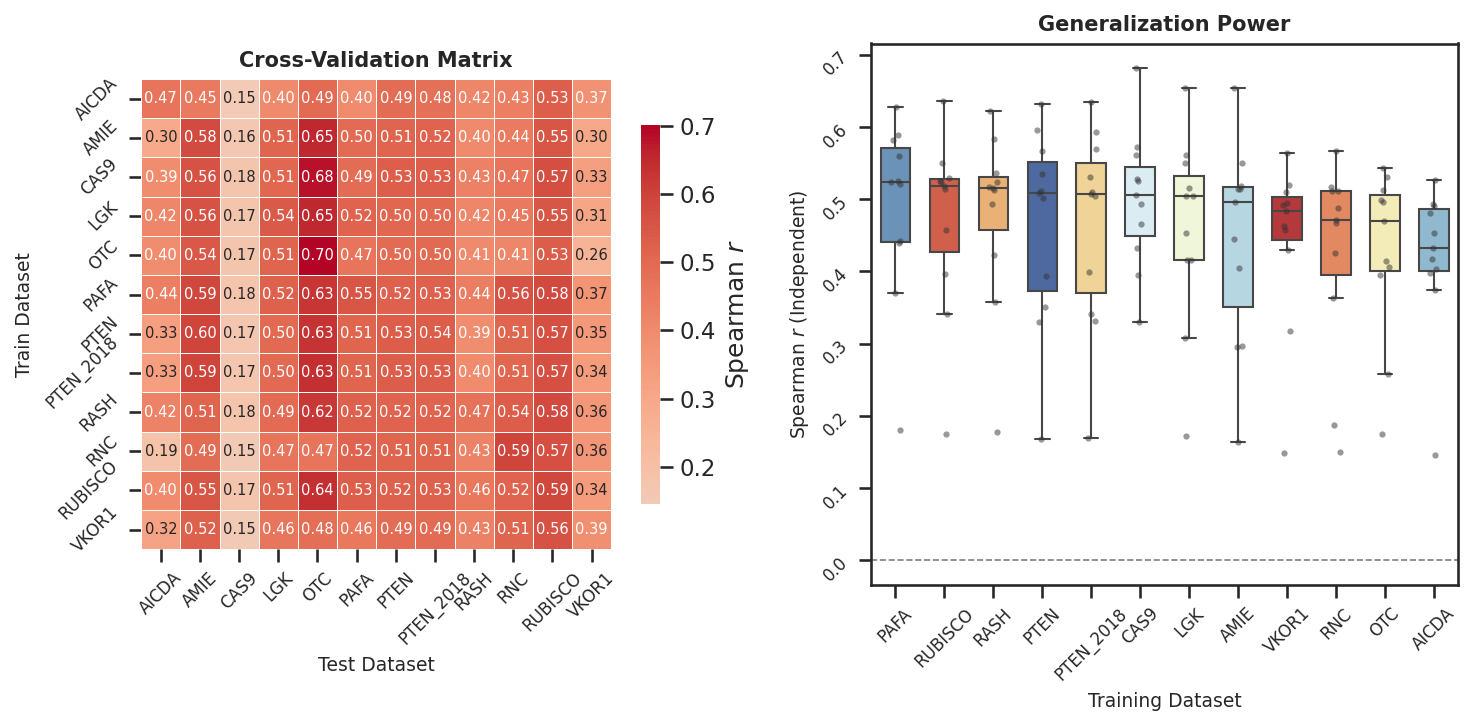

In [9]:
from scripts.plot import plot_cv_results

CSV_PATH = "/share/home/wangtb/enzyme_shells/analysis/exp_combination.csv"

plot_cv_results(CSV_PATH)

/share/home/wangtb/enzyme_shells/analysis/scripts/plot.py:104: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_delta.index, y=avg_delta.values, palette=colors, ax=ax2)
/share/home/wangtb/enzyme_shells/analysis/scripts/plot.py:115: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Model', y='r', data=df_long, palette="Pastel1", showfliers=False, ax=ax3, width=0.5)


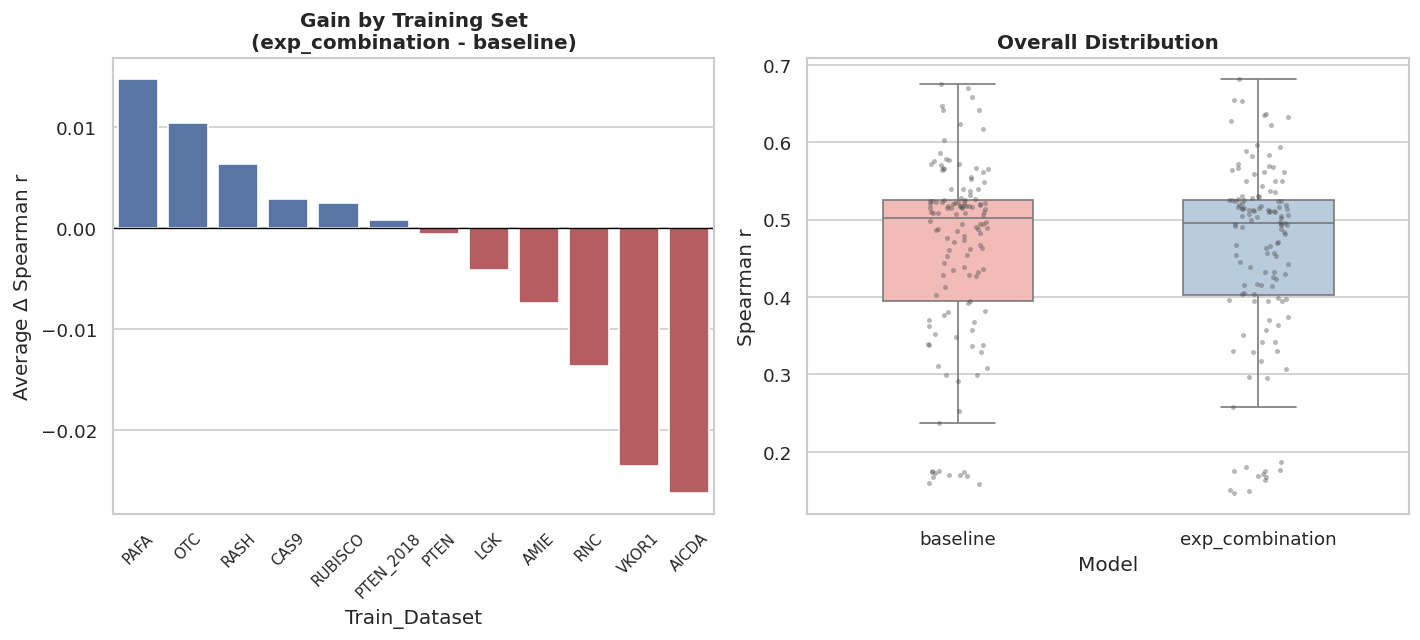

In [11]:
from scripts.plot import compare_cv_results

# 默认是 2 减去 1
CSV_1 = "/share/home/wangtb/enzyme_shells/analysis/baseline.csv"
CSV_2 = "/share/home/wangtb/enzyme_shells/analysis/exp_combination.csv"

compare_cv_results(CSV_1, CSV_2)

对d作exp变换，作为共同的权重，去加权三种特征的线性组合

In [12]:
import os
from scripts.data_utils import load_all_datasets, SCORES
from scripts.engine import run_cross_validation
import numpy as np

DATA_DIR = "/share/home/wangtb/enzyme_shells/activity_data"
OUT_DIR = "/share/home/wangtb/enzyme_shells/analysis"
OUT_NAME = "single_exp_combination.csv"

def predict(P, d, X):
    y_pred = ((
        P[0] * X[:,0] +
        P[1] * X[:,1] +
        P[2] * X[:,2]) * np.exp(P[3] * d) +
        P[4]
    )
    return y_pred

def objective(P, d, X, y_true, predict_fn, alpha=0.1):
    y_pred = predict_fn(P, d, X)
    
    s_diff = y_pred[:, None] - y_pred[None, :]
    y_diff = y_true[:, None] - y_true[None, :]
    mask = y_diff > 0
    valid_diffs = s_diff[mask]
    rank_loss = np.logaddexp(0, -valid_diffs).sum()
    
    l2_penalty = alpha * np.sum(P[:-1]**2)
    
    return rank_loss + l2_penalty

datasets = load_all_datasets(DATA_DIR)

num_params = 5
rng = np.random.RandomState(42)
p0 = rng.uniform(-1, 1, size=num_params)
print(f"初始参数: {p0}")

results_df = run_cross_validation(
    datasets, 
    predict_fn=predict, 
    objective_fn=objective, 
    p0=p0, 
    scores_cols=SCORES,
    alpha=0.1
)

if not os.path.exists(OUT_DIR): os.makedirs(OUT_DIR)
results_df.to_csv(os.path.join(OUT_DIR, OUT_NAME), index=False)
print("Done!")

初始参数: [-0.25091976  0.90142861  0.46398788  0.19731697 -0.68796272]
正在启动任务：PTEN.csv
正在启动任务：OTC.csv
正在启动任务：PTEN_2018.csv
正在启动任务：RNC.csv
正在启动任务：AICDA.csv
正在启动任务：CAS9.csv
正在启动任务：RASH.csv
正在启动任务：VKOR1.csv
正在启动任务：RUBISCO.csv
正在启动任务：AMIE.csv
正在启动任务：PAFA.csv
正在启动任务：LGK.csv
Done!


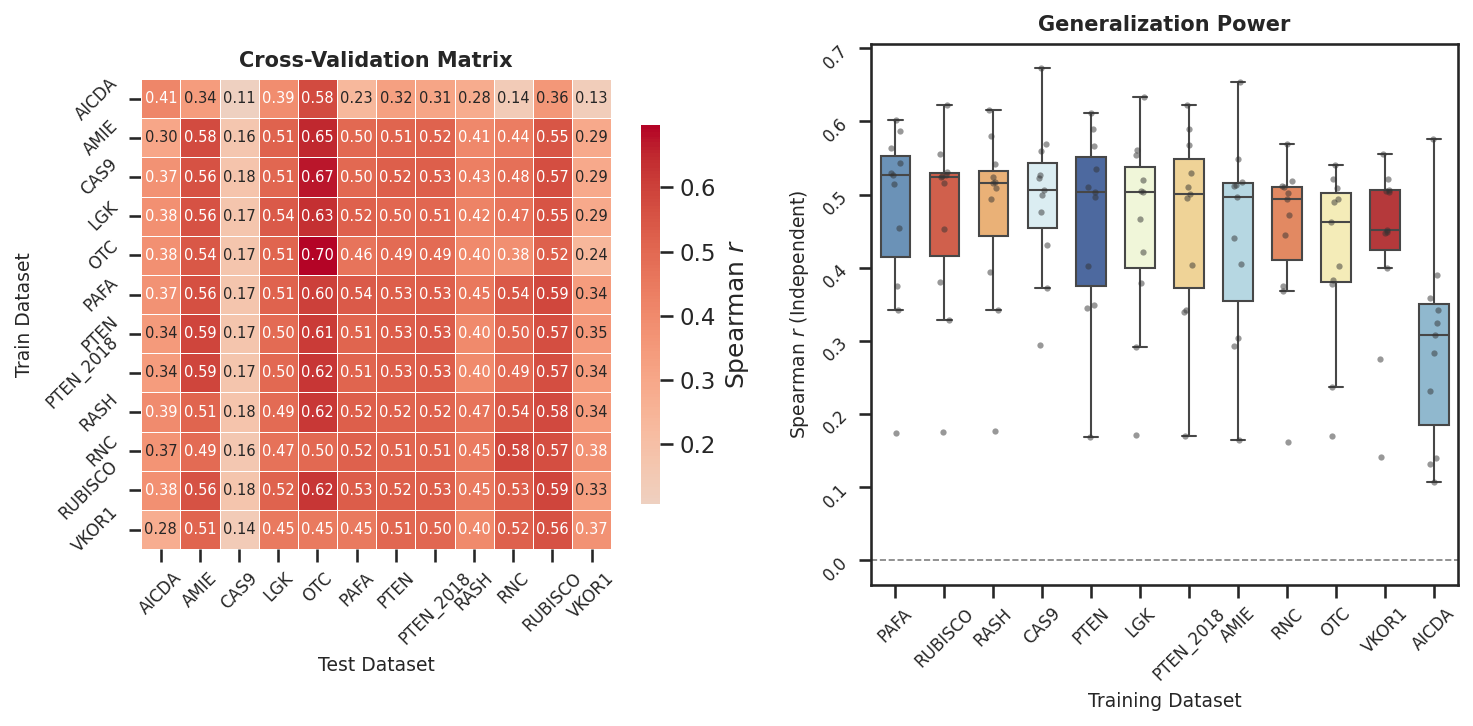

In [13]:
from scripts.plot import plot_cv_results

CSV_PATH = "/share/home/wangtb/enzyme_shells/analysis/single_exp_combination.csv"

plot_cv_results(CSV_PATH)

/share/home/wangtb/enzyme_shells/analysis/scripts/plot.py:104: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_delta.index, y=avg_delta.values, palette=colors, ax=ax2)
/share/home/wangtb/enzyme_shells/analysis/scripts/plot.py:115: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Model', y='r', data=df_long, palette="Pastel1", showfliers=False, ax=ax3, width=0.5)


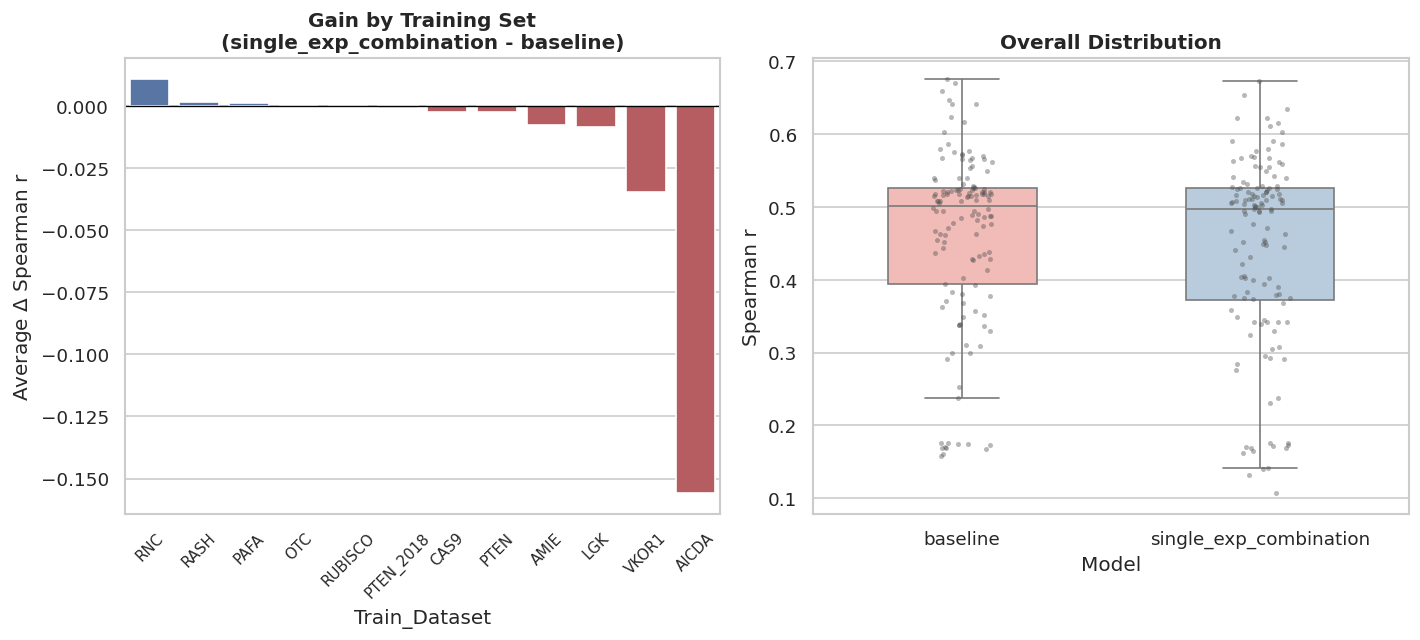

In [14]:
from scripts.plot import compare_cv_results

# 默认是 2 减去 1
CSV_1 = "/share/home/wangtb/enzyme_shells/analysis/baseline.csv"
CSV_2 = "/share/home/wangtb/enzyme_shells/analysis/single_exp_combination.csv"

compare_cv_results(CSV_1, CSV_2)

发现距离d加到e指数再去和特征相乘，得到的效果差于baseline；现在，考虑使用1-exp(-d)作为权重，去加权三种特征的线性组合，看看效果如何。

In [1]:
import os
from scripts.data_utils import load_all_datasets, SCORES
from scripts.engine import run_cross_validation
import numpy as np

DATA_DIR = "/share/home/wangtb/enzyme_shells/activity_data"
OUT_DIR = "/share/home/wangtb/enzyme_shells/analysis"
OUT_NAME = "linear_exp(-d).csv"

def predict(P, d, X):
    y_pred = (
        P[0]*X[:,0] + 
        P[1]*X[:,1] + 
        P[2]*X[:,2] + 
        P[3]*(1 - np.exp(-d)) +  # 活性随d上升但逐渐饱和
        P[4]
    )
    return y_pred

def objective(P, d, X, y_true, predict_fn, alpha=0.1):
    y_pred = predict_fn(P, d, X)
    
    s_diff = y_pred[:, None] - y_pred[None, :]
    y_diff = y_true[:, None] - y_true[None, :]
    mask = y_diff > 0
    valid_diffs = s_diff[mask]
    rank_loss = np.logaddexp(0, -valid_diffs).sum()
    
    l2_penalty = alpha * np.sum(P[:-1]**2)
    
    return rank_loss + l2_penalty

datasets = load_all_datasets(DATA_DIR)

num_params = 5
rng = np.random.RandomState(42)
p0 = rng.uniform(-1, 1, size=num_params)
print(f"初始参数: {p0}")

results_df = run_cross_validation(
    datasets, 
    predict_fn=predict, 
    objective_fn=objective, 
    p0=p0, 
    scores_cols=SCORES,
    alpha=0.1
)

if not os.path.exists(OUT_DIR): os.makedirs(OUT_DIR)
results_df.to_csv(os.path.join(OUT_DIR, OUT_NAME), index=False)
print("Done!")

初始参数: [-0.25091976  0.90142861  0.46398788  0.19731697 -0.68796272]
正在启动任务：PTEN.csv
正在启动任务：LGK.csv
正在启动任务：PTEN_2018.csv
正在启动任务：AMIE.csv
正在启动任务：RUBISCO.csv
正在启动任务：RASH.csv
正在启动任务：RNC.csv
正在启动任务：CAS9.csv
正在启动任务：AICDA.csv
正在启动任务：VKOR1.csv
正在启动任务：OTC.csv
正在启动任务：PAFA.csv
Done!


/share/home/wangtb/enzyme_shells/analysis/scripts/plot.py:104: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_delta.index, y=avg_delta.values, palette=colors, ax=ax2)
/share/home/wangtb/enzyme_shells/analysis/scripts/plot.py:115: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Model', y='r', data=df_long, palette="Pastel1", showfliers=False, ax=ax3, width=0.5)


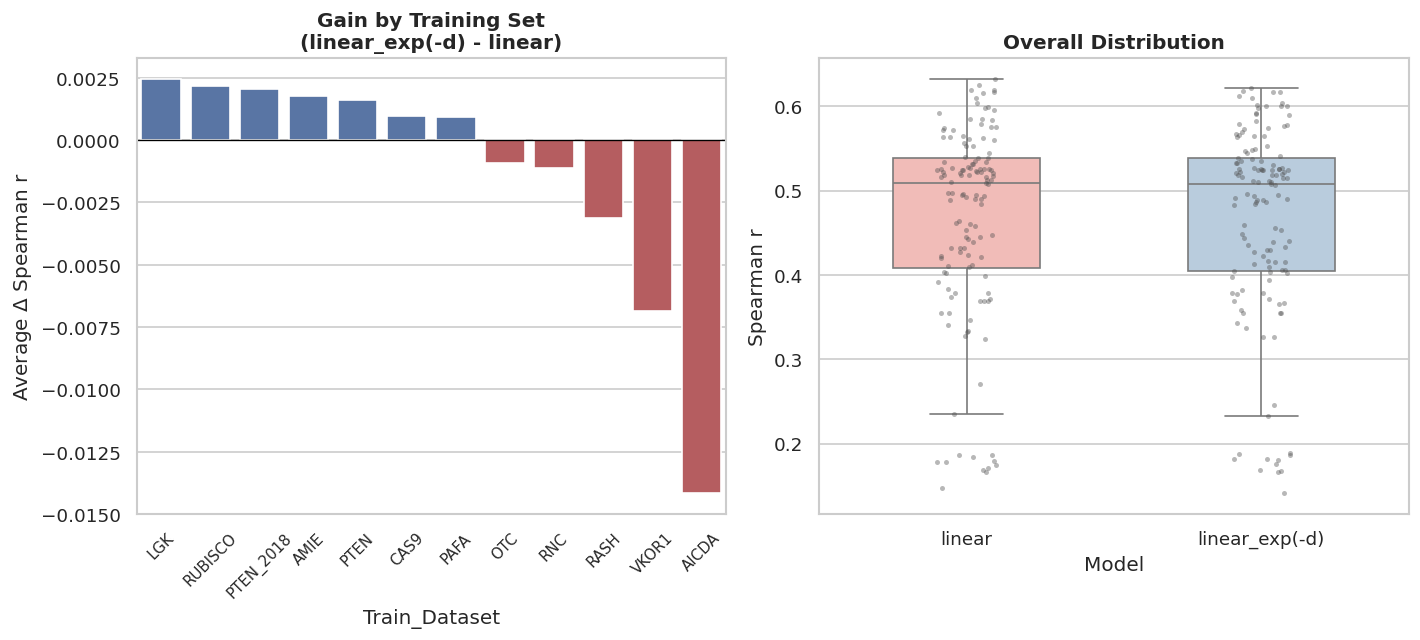

In [3]:
from scripts.plot import compare_cv_results

# 默认是 2 减去 1
CSV_1 = "/share/home/wangtb/enzyme_shells/analysis/linear.csv"
CSV_2 = "/share/home/wangtb/enzyme_shells/analysis/linear_exp(-d).csv"

compare_cv_results(CSV_1, CSV_2)

这个版本的代码其实很接近linear的结果，因为1-exp(-d)本质上随着d增加是增加的，和直接把d乘上权重加上去类似，但是从结果来看，这个版本略差

再试试d放分母的情况

In [4]:
import os
from scripts.data_utils import load_all_datasets, SCORES
from scripts.engine import run_cross_validation
import numpy as np

DATA_DIR = "/share/home/wangtb/enzyme_shells/activity_data"
OUT_DIR = "/share/home/wangtb/enzyme_shells/analysis"
OUT_NAME = "over_d.csv"

def predict(P, d, X):
    alpha = P[5]
    beta  = P[6]
    
    y_pred = (
        P[0]*X[:,0]/(beta + alpha*d) +
        P[1]*X[:,1]/(beta + alpha*d) +
        P[2]*X[:,2]/(beta + alpha*d) +
        P[3]*d +
        P[4]
    )

    return y_pred

def objective(P, d, X, y_true, predict_fn, alpha=0.1):
    y_pred = predict_fn(P, d, X)
    
    s_diff = y_pred[:, None] - y_pred[None, :]
    y_diff = y_true[:, None] - y_true[None, :]
    mask = y_diff > 0
    valid_diffs = s_diff[mask]
    rank_loss = np.logaddexp(0, -valid_diffs).sum()
    
    l2_penalty = alpha * np.sum(P[:-1]**2)
    
    return rank_loss + l2_penalty

datasets = load_all_datasets(DATA_DIR)

num_params = 7
rng = np.random.RandomState(42)
p0 = rng.uniform(-1, 1, size=num_params)
print(f"初始参数: {p0}")

results_df = run_cross_validation(
    datasets, 
    predict_fn=predict, 
    objective_fn=objective, 
    p0=p0, 
    scores_cols=SCORES,
    alpha=0.1
)

if not os.path.exists(OUT_DIR): os.makedirs(OUT_DIR)
results_df.to_csv(os.path.join(OUT_DIR, OUT_NAME), index=False)
print("Done!")

初始参数: [-0.25091976  0.90142861  0.46398788  0.19731697 -0.68796272 -0.68801096
 -0.88383278]
正在启动任务：RASH.csv
正在启动任务：PTEN.csv
正在启动任务：LGK.csv
正在启动任务：AMIE.csv
正在启动任务：PTEN_2018.csv
正在启动任务：RNC.csv
正在启动任务：CAS9.csv
正在启动任务：VKOR1.csv
正在启动任务：PAFA.csv
正在启动任务：AICDA.csv
正在启动任务：OTC.csv
正在启动任务：RUBISCO.csv
Done!


/share/home/wangtb/enzyme_shells/analysis/scripts/plot.py:104: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_delta.index, y=avg_delta.values, palette=colors, ax=ax2)
/share/home/wangtb/enzyme_shells/analysis/scripts/plot.py:115: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Model', y='r', data=df_long, palette="Pastel1", showfliers=False, ax=ax3, width=0.5)


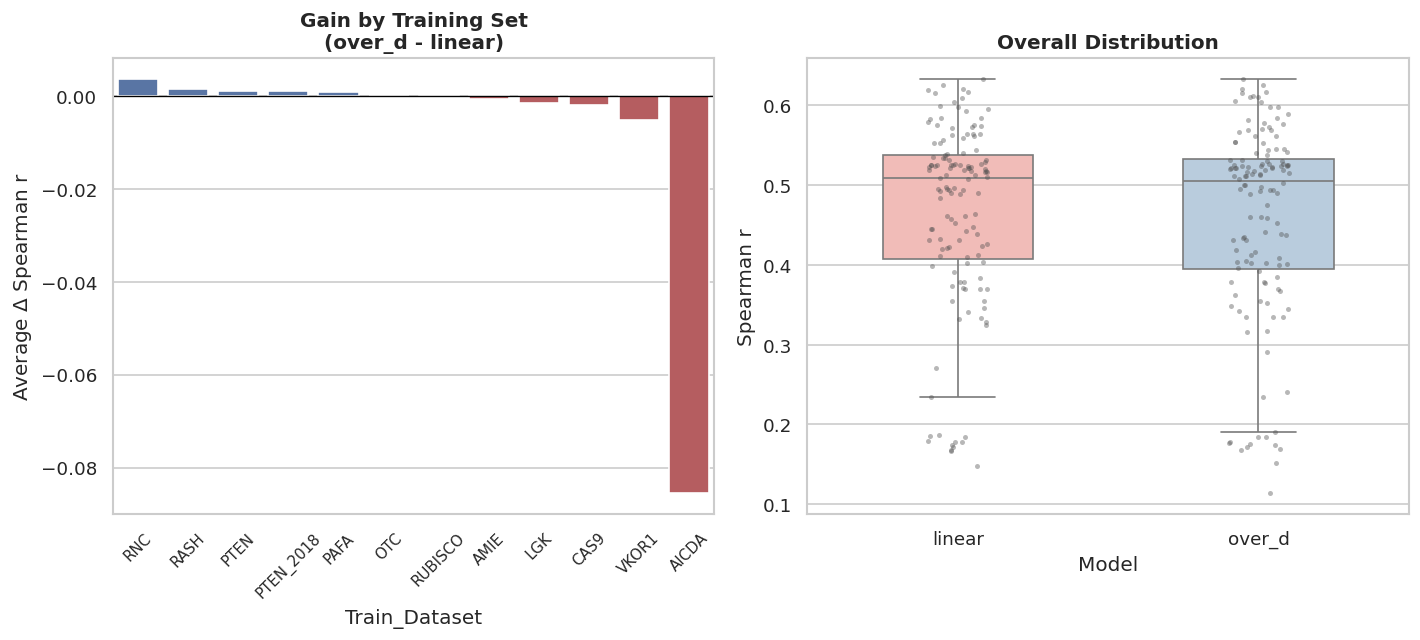

In [5]:
from scripts.plot import compare_cv_results

# 默认是 2 减去 1
CSV_1 = "/share/home/wangtb/enzyme_shells/analysis/linear.csv"
CSV_2 = "/share/home/wangtb/enzyme_shells/analysis/over_d.csv"

compare_cv_results(CSV_1, CSV_2)